Upload do arquivo

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Fifa_world_cup_matches.csv to Fifa_world_cup_matches.csv


Instalando dependências

In [ ]:
!pip install xgboost --quiet
print("Bora Brasillll!")

Bora Brasillll!


Importar as bibliotecas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
import xgboost as xgb
import warnings
warnings.filterwarnings("ignore")

print("Bibliotecas carregadas!")

Bibliotecas carregadas!


Carregar o CSV

In [ ]:
df = pd.read_csv("Fifa_world_cup_matches.csv")

print(f" Linhas: {df.shape[0]} Colunas: {df.shape[1]}")
df.head()

 Linhas: 64 Colunas: 88


,team1,team2,possession team1,possession team2,possession in contest,number of goals team1,number of goals team2,date,hour,category,...,penalties scored team1,penalties scored team2,goal preventions team1,goal preventions team2,own goals team1,own goals team2,forced turnovers team1,forced turnovers team2,defensive pressures applied team1,defensive pressures applied team2
0,QATAR,ECUADOR,42%,50%,8%,0,2,20 NOV 2022,17 : 00,Group A,...,0,1,6,5,0,0,52,72,256,279
1,ENGLAND,IRAN,72%,19%,9%,6,2,21 NOV 2022,14 : 00,Group B,...,0,1,8,13,0,0,63,72,139,416
2,SENEGAL,NETHERLANDS,44%,45%,11%,0,2,21 NOV 2022,17 : 00,Group A,...,0,0,9,15,0,0,63,73,263,251
3,UNITED STATES,WALES,51%,39%,10%,1,1,21 NOV 2022,20 : 00,Group B,...,0,1,7,7,0,0,81,72,242,292
4,ARGENTINA,SAUDI ARABIA,64%,24%,12%,1,2,22 NOV 2022,11 : 00,Group C,...,1,0,4,14,0,0,65,80,163,361


Inspecionando os dados

In [ ]:
print("Tipos de dados:")
print(df.dtypes)

print("\nValores nulos:")
print(df.isnull().sum().sum(), "nulos no total")

print("\nFases do torneio:")
print(df["category"].value_counts())

Tipos de dados:
team1                                object
team2                                object
possession team1                     object
possession team2                     object
possession in contest                object
                                      ...  
own goals team2                       int64
forced turnovers team1                int64
forced turnovers team2                int64
defensive pressures applied team1     int64
defensive pressures applied team2     int64
Length: 88, dtype: object

Valores nulos:
0 nulos no total

Fases do torneio:
category
Round of 16                 8
Group B                     6
Group C                     6
Group D                     6
Group A                     6
Group F                     6
Group E                     6
Group G                     6
Group H                     6
Quarter-final               4
Semi-final                  2
Play-off for third place    1
Final                       1
Name: count, dtype: int

Limpeza dos dados

In [ ]:
for col in ["possession team1", "possession team2", "possession in contest"]:
    df[col] = df[col].str.replace("%", "").str.strip().astype(float) / 100

df["date"] = pd.to_datetime(df["date"], format="%d %b %Y")

df.columns = df.columns.str.strip()

df["team1"] = df["team1"].str.strip().str.upper()
df["team2"] = df["team2"].str.strip().str.upper()

print("Posse de bola após conversão:")
print(df[["possession team1", "possession team2"]].head(3))

print("\nTipos corrigidos:")
print(df[["possession team1", "date"]].dtypes)

Posse de bola após conversão:
   possession team1  possession team2
0              0.42              0.50
1              0.72              0.19
2              0.44              0.45

Tipos corrigidos:
possession team1           float64
date                datetime64[ns]
dtype: object


Transformando dados brutos em informações

In [ ]:
rows = []

for _, row in df.iterrows():
    for side, opp in [("team1", "team2"), ("team2", "team1")]:

        goals    = row[f"number of goals {side}"]
        g_against = row[f"number of goals {opp}"]

        result = "win" if goals > g_against else "loss" if goals < g_against else "draw"

        rows.append({
            "team"               : row[side],
            "phase"              : row["category"],
            "result"             : result,
            "goals_scored"       : goals,
            "goals_conceded"     : g_against,
            "goal_diff"          : goals - g_against,
            "possession"         : row[f"possession {side}"],
            "total_attempts"     : row[f"total attempts {side}"],
            "on_target"          : row[f"on target attempts {side}"],
            "passes"             : row[f"passes {side}"],
            "passes_completed"   : row[f"passes completed {side}"],
            "yellow_cards"       : row[f"yellow cards {side}"],
            "red_cards"          : row[f"red cards {side}"],
            "defensive_pressures": row[f"defensive pressures applied {side}"],
            "goal_preventions"   : row[f"goal preventions {side}"],
            "assists"            : row[f"assists {side}"],
        })

df_teams = pd.DataFrame(rows)


df_teams["shot_accuracy"] = df_teams["on_target"] / (df_teams["total_attempts"] + 1e-5)
df_teams["pass_accuracy"] = df_teams["passes_completed"] / (df_teams["passes"] + 1e-5)

print(f"Dataset expandido: {df_teams.shape}")
df_teams.head(4)

Dataset expandido: (128, 18)


,team,phase,result,goals_scored,goals_conceded,goal_diff,possession,total_attempts,on_target,passes,passes_completed,yellow_cards,red_cards,defensive_pressures,goal_preventions,assists,shot_accuracy,pass_accuracy
0,QATAR,Group A,loss,0,2,-2,0.42,5,0,450,381,4,0,256,6,0,0.000000,0.846667
1,ECUADOR,Group A,win,2,0,2,0.50,6,3,480,409,2,0,279,5,1,0.499999,0.852083
2,ENGLAND,Group B,win,6,2,4,0.72,13,7,809,730,0,0,139,8,6,0.538461,0.902349
3,IRAN,Group B,loss,2,6,-4,0.19,8,3,224,154,2,0,416,13,1,0.375000,0.687500


Agregando estatísticas por seleção

In [ ]:
# Peso por fase
phase_weight = {
    "Group A": 1, "Group B": 1, "Group C": 1, "Group D": 1,
    "Group E": 1, "Group F": 1, "Group G": 1, "Group H": 1,
    "Round of 16": 2, "Quarter-final": 3,
    "Semi-final": 4, "Play-off for third place": 3, "Final": 5
}
df_teams["phase_weight"] = df_teams["phase"].map(phase_weight).fillna(1)

# Fase mais longe que cada time chegou
phase_order = {
    "Group A": 1, "Group B": 1, "Group C": 1, "Group D": 1,
    "Group E": 1, "Group F": 1, "Group G": 1, "Group H": 1,
    "Round of 16": 2, "Quarter-final": 3,
    "Semi-final": 4, "Play-off for third place": 4, "Final": 5
}
df_teams["phase_num"] = df_teams["phase"].map(phase_order)

# Médias por time
numeric_cols = [
    "goals_scored", "goals_conceded", "goal_diff",
    "possession", "total_attempts", "on_target",
    "passes", "passes_completed", "yellow_cards",
    "red_cards", "defensive_pressures", "goal_preventions",
    "assists", "shot_accuracy", "pass_accuracy"
]

df_agg = df_teams.groupby("team")[numeric_cols].mean().reset_index()

wins   = df_teams[df_teams["result"] == "win"].groupby("team").size().rename("wins")
draws  = df_teams[df_teams["result"] == "draw"].groupby("team").size().rename("draws")
losses = df_teams[df_teams["result"] == "loss"].groupby("team").size().rename("losses")
total  = df_teams.groupby("team").size().rename("total_games")
phase  = df_teams.groupby("team")["phase_num"].max().rename("max_phase")

df_agg = df_agg.merge(wins,   on="team", how="left")
df_agg = df_agg.merge(draws,  on="team", how="left")
df_agg = df_agg.merge(losses, on="team", how="left")
df_agg = df_agg.merge(total,  on="team", how="left")
df_agg = df_agg.merge(phase,  on="team", how="left")

df_agg[["wins", "draws", "losses"]] = df_agg[["wins", "draws", "losses"]].fillna(0)
df_agg["win_rate"] = df_agg["wins"] / df_agg["total_games"]
df_agg["points"]   = df_agg["wins"] * 3 + df_agg["draws"]

print(f"Times agregados: {df_agg.shape[0]}")
print(df_agg[["team", "wins", "draws", "losses", "points", "max_phase"]].sort_values("points", ascending=False).to_string(index=False))

Times agregados: 32
          team  wins  draws  losses  points  max_phase
        FRANCE   5.0    1.0     1.0    16.0          5
     ARGENTINA   4.0    2.0     1.0    14.0          5
       MOROCCO   3.0    2.0     2.0    11.0          4
   NETHERLANDS   3.0    2.0     0.0    11.0          3
       ENGLAND   3.0    1.0     1.0    10.0          3
        BRAZIL   3.0    1.0     1.0    10.0          3
       CROATIA   2.0    4.0     1.0    10.0          4
      PORTUGAL   3.0    0.0     2.0     9.0          3
         JAPAN   2.0    1.0     1.0     7.0          2
       SENEGAL   2.0    0.0     2.0     6.0          2
     AUSTRALIA   2.0    0.0     2.0     6.0          2
   SWITZERLAND   2.0    0.0     2.0     6.0          2
         SPAIN   1.0    2.0     1.0     5.0          2
 UNITED STATES   1.0    2.0     1.0     5.0          2
       GERMANY   1.0    1.0     1.0     4.0          1
       BELGIUM   1.0    1.0     1.0     4.0          1
       URUGUAY   1.0    1.0     1.0     4.0  

Preparando os dados para o modelo

In [ ]:
from sklearn.preprocessing import MinMaxScaler

df_agg["potencial_tatico"] = (
    df_agg["goal_diff"]     * 0.30 +
    df_agg["win_rate"]      * 0.30 +
    df_agg["shot_accuracy"] * 0.20 +
    df_agg["pass_accuracy"] * 0.10 +
    df_agg["goals_scored"]  * 0.10
)

scaler_target = MinMaxScaler()
df_agg["potencial_tatico"] = scaler_target.fit_transform(df_agg[["potencial_tatico"]])

feature_cols = [
    "goals_scored", "goals_conceded", "goal_diff",
    "possession", "total_attempts", "on_target",
    "pass_accuracy", "shot_accuracy",
    "defensive_pressures", "goal_preventions",
    "yellow_cards", "assists", "win_rate"
]

X = df_agg[feature_cols].fillna(0)
y = df_agg["potencial_tatico"]

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=feature_cols)

print("Top 10 por potencial tatico:")
print(df_agg[["team", "potencial_tatico"]].sort_values("potencial_tatico", ascending=False).head(10).to_string(index=False))

Top 10 por potencial tatico:
       team  potencial_tatico
    ENGLAND          1.000000
   PORTUGAL          0.868661
     FRANCE          0.867889
NETHERLANDS          0.845359
      SPAIN          0.842847
  ARGENTINA          0.817919
     BRAZIL          0.791747
    GERMANY          0.629219
    ECUADOR          0.596784
      JAPAN          0.590003


Treinando o modelo

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=5,
    random_state=42
)

cv = KFold(n_splits=4, shuffle=True, random_state=42)
scores = cross_val_score(rf, X_scaled, y, cv=cv, scoring="r2")

print(f"R2 médio: {scores.mean():.3f}")
print(f"Desvio padrão: {scores.std():.3f}")

rf.fit(X_scaled, y)
print("\nModelo treinado.")

R2 médio: 0.901
Desvio padrão: 0.070

Modelo treinado.


Ranking 2026

In [ ]:
df_ranking = df_agg[["team", "potencial_tatico", "win_rate", "points"]].copy()
df_ranking = df_ranking.sort_values("potencial_tatico", ascending=False).reset_index(drop=True)
df_ranking.index += 1

print("Potencial tatico projetado para 2026:\n")
print(df_ranking.to_string())

Potencial tatico projetado para 2026:

              team  potencial_tatico  win_rate  points
1          ENGLAND          1.000000  0.600000    10.0
2         PORTUGAL          0.868661  0.600000     9.0
3           FRANCE          0.867889  0.714286    16.0
4      NETHERLANDS          0.845359  0.600000    11.0
5            SPAIN          0.842847  0.250000     5.0
6        ARGENTINA          0.817919  0.571429    14.0
7           BRAZIL          0.791747  0.600000    10.0
8          GERMANY          0.629219  0.333333     4.0
9          ECUADOR          0.596784  0.333333     4.0
10           JAPAN          0.590003  0.500000     7.0
11        CAMEROON          0.536855  0.333333     4.0
12         MOROCCO          0.528582  0.428571    11.0
13         CROATIA          0.528114  0.285714    10.0
14         URUGUAY          0.472482  0.333333     4.0
15         TUNISIA          0.454910  0.333333     4.0
16         SENEGAL          0.442960  0.500000     6.0
17       AUSTRALIA        

Visualização

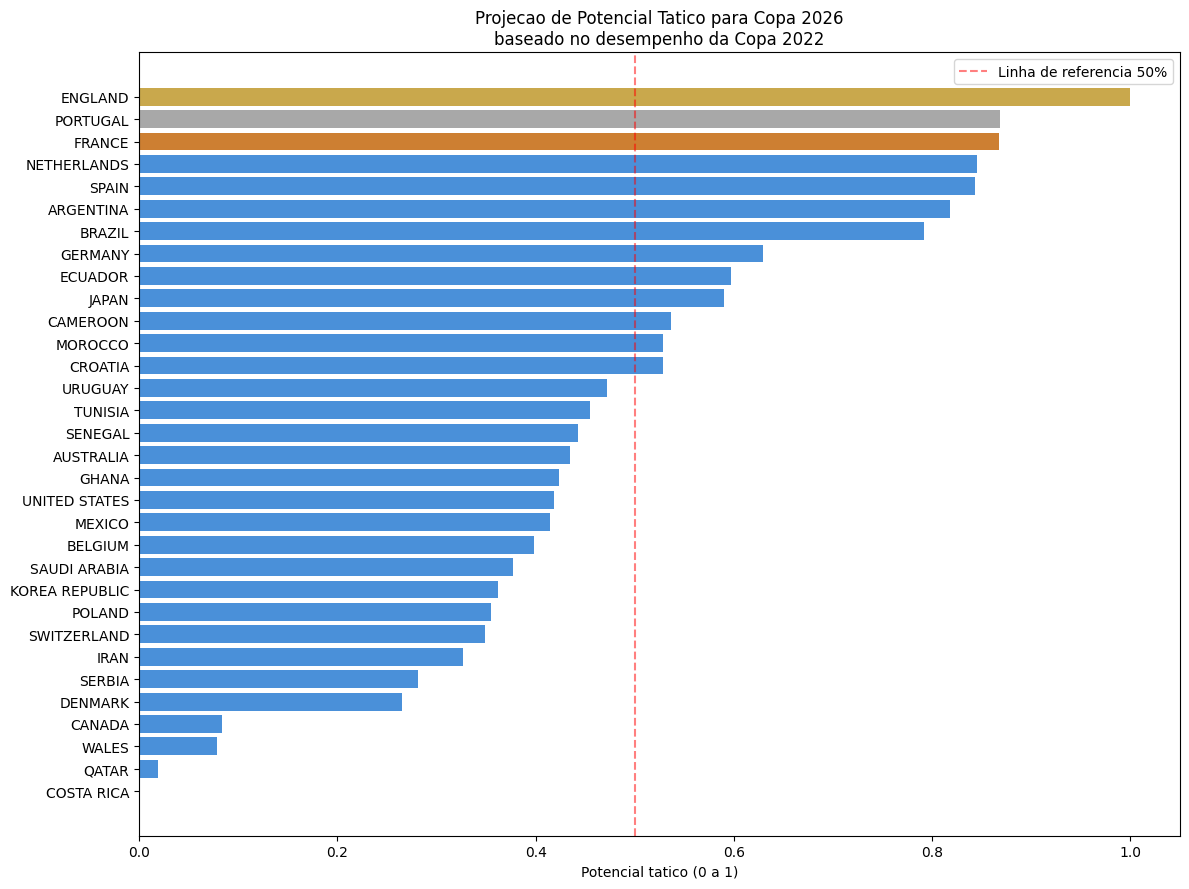

In [ ]:
plt.figure(figsize=(12, 9))

cores = ["#C9A84C" if i == 1 else "#A8A8A8" if i == 2 else
         "#CD7F32" if i == 3 else "#4a90d9"
         for i in df_ranking.index]

plt.barh(df_ranking["team"][::-1],
         df_ranking["potencial_tatico"][::-1],
         color=cores[::-1])

plt.xlabel("Potencial tatico (0 a 1)")
plt.title("Projecao de Potencial Tatico para Copa 2026\nbaseado no desempenho da Copa 2022")
plt.axvline(x=0.5, color="red", linestyle="--", alpha=0.5, label="Linha de referencia 50%")
plt.legend()
plt.tight_layout()
plt.show()

Projeção 7 primeiros - tabela

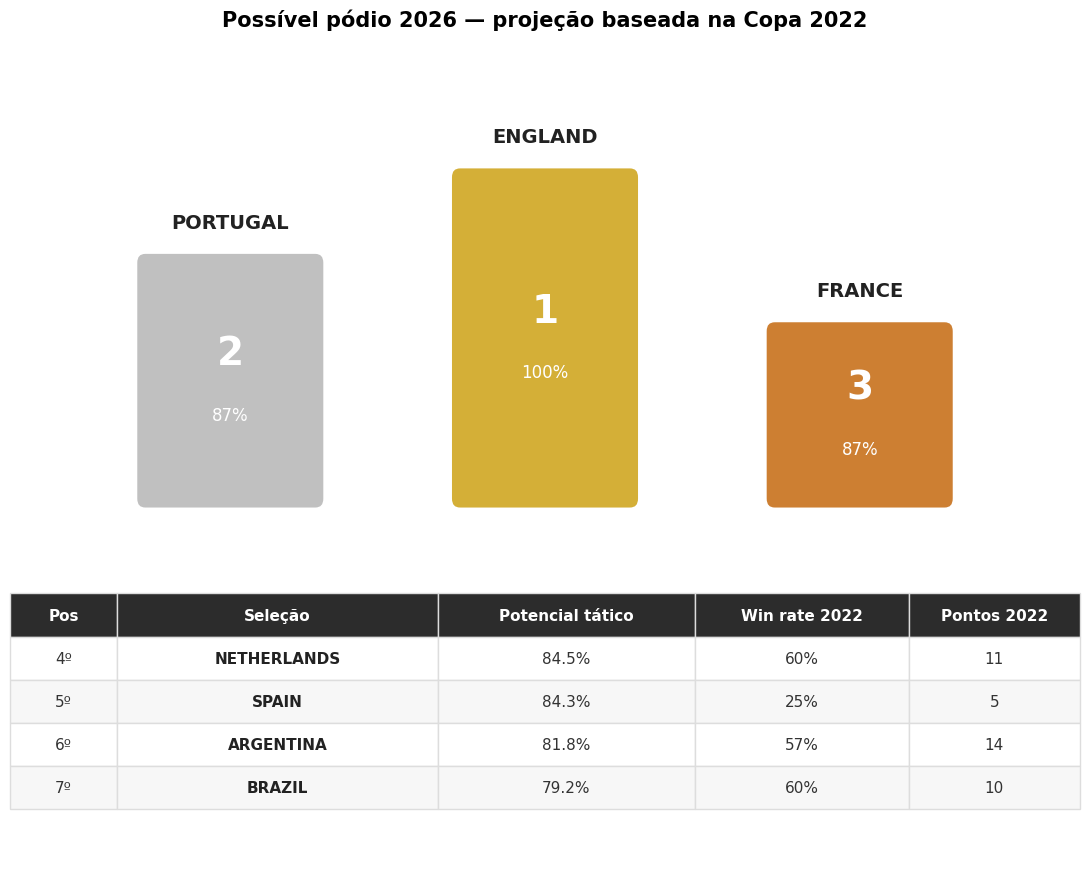

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

top7 = df_ranking.head(7).copy()
top7["posicao"] = range(1, 8)

fig = plt.figure(figsize=(11, 9))
gs = fig.add_gridspec(2, 1, height_ratios=[1.3, 1])

# ── PARTE 1: PODIO (top 3) ──
ax1 = fig.add_subplot(gs[0])
ax1.axis("off")

podio_dados = top7.head(3).reset_index(drop=True)
alturas   = [0.75, 1.0, 0.55]
ordem_x   = [0, 1, 2]
cores     = ["#C0C0C0", "#D4AF37", "#CD7F32"]
labels_pos = ["2", "1", "3"]
nomes_corrigidos = [podio_dados.iloc[1]["team"], podio_dados.iloc[0]["team"], podio_dados.iloc[2]["team"]]
valores_corrigidos = [podio_dados.iloc[1]["potencial_tatico"],
                      podio_dados.iloc[0]["potencial_tatico"],
                      podio_dados.iloc[2]["potencial_tatico"]]

largura = 0.6
for i, (x, altura, cor, label, nome, valor) in enumerate(
    zip(ordem_x, alturas, cores, labels_pos, nomes_corrigidos, valores_corrigidos)
):
    rect = patches.FancyBboxPatch(
        (x - largura/2, 0), largura, altura,
        boxstyle="round,pad=0,rounding_size=0.03",
        facecolor=cor, edgecolor="white", linewidth=2
    )
    ax1.add_patch(rect)

    ax1.text(x, altura + 0.06, nome, ha="center", va="bottom",
              fontsize=14, weight="bold", color="#222222")
    ax1.text(x, altura/2 + 0.08, label, ha="center", va="center",
              fontsize=28, weight="bold", color="white")
    ax1.text(x, altura/2 - 0.10, f"{valor*100:.0f}%", ha="center", va="center",
              fontsize=12, color="white")

ax1.set_xlim(-0.7, 2.7)
ax1.set_ylim(0, 1.35)
ax1.set_title("Possível pódio 2026 — projeção baseada na Copa 2022",
               fontsize=15, weight="bold", pad=15)

# ── PARTE 2: TABELA (posicoes 4 a 7) ──
ax2 = fig.add_subplot(gs[1])
ax2.axis("off")

resto = top7.iloc[3:].reset_index(drop=True)
tabela_dados = []
for _, row in resto.iterrows():
    tabela_dados.append([
        f"{int(row['posicao'])}º",
        row["team"],
        f"{row['potencial_tatico']*100:.1f}%",
        f"{row['win_rate']*100:.0f}%",
        f"{int(row['points'])}"
    ])

colunas = ["Pos", "Seleção", "Potencial tático", "Win rate 2022", "Pontos 2022"]

tabela = ax2.table(
    cellText=tabela_dados,
    colLabels=colunas,
    cellLoc="center",
    loc="center",
    colWidths=[0.10, 0.30, 0.24, 0.20, 0.16]
)

tabela.auto_set_font_size(False)
tabela.set_fontsize(11)
tabela.scale(1, 2.0)

for (row, col), cell in tabela.get_celld().items():
    cell.set_edgecolor("#dddddd")
    cell.set_linewidth(1)
    if row == 0:
        cell.set_facecolor("#2c2c2c")
        cell.set_text_props(color="white", weight="bold")
    else:
        cell.set_facecolor("#f7f7f7" if row % 2 == 0 else "#ffffff")
        cell.set_text_props(color="#333333")
        if col == 1:
            cell.set_text_props(weight="bold", color="#222222")

plt.tight_layout()
plt.savefig("podio_2026.png", dpi=150, bbox_inches="tight")
plt.show()